<a href="https://colab.research.google.com/github/Yangyang5750858/yangyang5750858-DataScience-GenAI-Submissions/blob/main/ML_lendingclub_YANGYANG_CHEN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

cyang1143_loanlendingclub_path = kagglehub.dataset_download('cyang1143/loanlendingclub')

print('Data source import complete.')


# **DATA PREPROCESSING**

In [ ]:
#Import libraries for preprocessing
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Charge the data
df = pd.read_csv('/kaggle/input/loanlendingclub/Loan_Lending_Club (USE THIS ONE).csv')


<ipython-input-2-bcb448cd29c7>:2: DtypeWarning: Columns (48,58,117) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/loanlendingclub/Loan_Lending_Club (USE THIS ONE).csv')


In [ ]:
df = df.sample(n=10000, random_state=42)

# **Deal with null values**

In [ ]:
#Check null values
df.isnull().sum()

Unnamed: 0                                       0
id                                               0
loan_amnt                                        0
funded_amnt                                      0
funded_amnt_inv                                  0
                                              ... 
hardship_loan_status                          9652
orig_projected_additional_accrued_interest    9560
hardship_payoff_balance_amount                9544
hardship_last_payment_amount                  9544
debt_settlement_flag                             0
Length: 142, dtype: int64

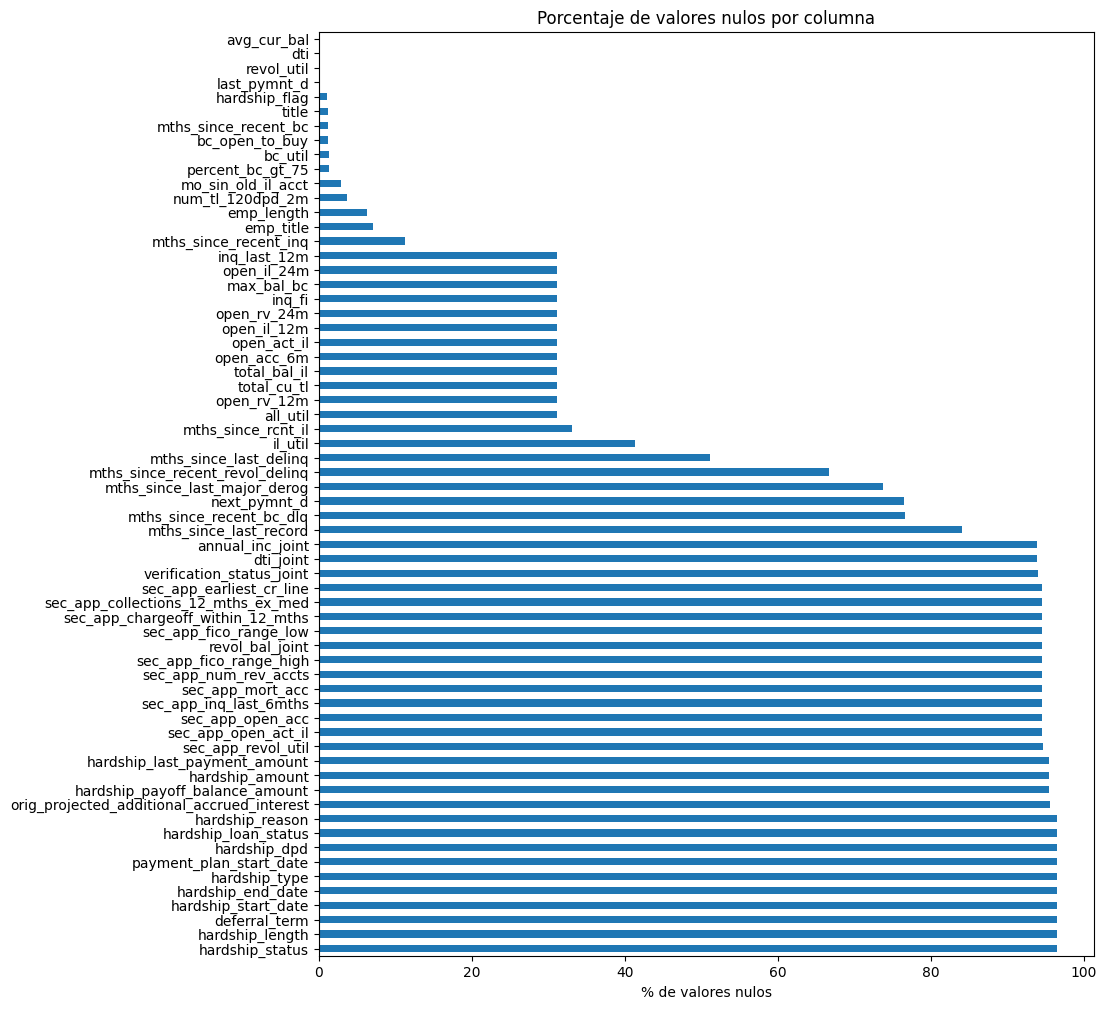

In [ ]:
#Show percentage of null values of each column
null_percentage = df.isnull().mean().sort_values(ascending=False) * 100
null_percentage[null_percentage > 0].plot(kind='barh', figsize=(10,12))
plt.title('Porcentaje de valores nulos por columna')
plt.xlabel('% de valores nulos')
plt.show()

In [ ]:
#Eliminating the column Unnamed: 0, because it's not useful
df = df.drop('Unnamed: 0', axis=1)

In [ ]:
#Separate columns of numerical and categorical
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

#Fill numerical with median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

#Fill categórical with mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

<ipython-input-7-42d662abf664>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
<ipython-input-7-42d662abf664>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [ ]:
#Drop columns with more than 50% missing values
cols_to_drop = null_percentage[null_percentage > 50].index
df = df.drop(columns=cols_to_drop)

In [ ]:
#Check again null values
df.isnull().sum().sum()

0

# **Decide which categorical to include**

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
print(f"Columnas categóricas:\n{cat_cols}")

Columnas categóricas:
Index(['term', 'int_rate', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state',
       'earliest_cr_line', 'revol_util', 'initial_list_status', 'last_pymnt_d',
       'last_credit_pull_d', 'application_type', 'hardship_flag',
       'debt_settlement_flag'],
      dtype='object')


Our target variable is loan quality, ranging from "good" to "bad," but only considering loans that are already "closed." We need to filter it from the column loan status

In [ ]:
#See what variables we have in loan_status
df['loan_status'].value_counts()

loan_status
Fully Paid            6035
Current               2282
Charged Off           1612
Late (31-120 days)      43
In Grace Period         25
Late (16-30 days)        3
Name: count, dtype: int64

In [ ]:
#Filter now thw closed ones and create a copy of them
closed_statuses = ['Fully Paid', 'Charged Off', 'Default']
df_closed = df[df['loan_status'].isin(closed_statuses)].copy()

In [ ]:
#Convert our objectives into a binary column called loan_result
df_closed['loan_result'] = df_closed['loan_status'].apply(lambda x: 1 if x == 'Fully Paid' else 0)
df_closed.head(5)

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,debt_settlement_flag,loan_result
958693,10985103,10000.0,10000.0,10000.0,36 months,13.53%,339.50,B,B5,RedPrairie Developer,...,33.3,0.0,0.0,101449.0,21580.0,5400.0,25049.0,N,N,1
1931733,111671970,24550.0,24550.0,24550.0,60 months,15.05%,584.69,C,C4,Police officer,...,0.0,1.0,0.0,460562.0,75789.0,11100.0,84211.0,N,N,1
706759,142301137,12000.0,12000.0,12000.0,36 months,8.46%,378.59,A,A5,Sales associate,...,0.0,0.0,0.0,342555.0,8035.0,38700.0,0.0,N,N,1
1942278,111130949,3500.0,3500.0,3500.0,36 months,10.42%,113.63,B,B3,Forklift driver,...,0.0,0.0,0.0,18412.0,5407.0,8000.0,10412.0,N,N,1
1534444,83835463,24000.0,24000.0,24000.0,36 months,13.99%,820.15,C,C3,Table Games Supervisor,...,50.0,0.0,0.0,92200.0,50240.0,34500.0,20000.0,N,N,1


**Variables to drop** (low predictive value or too messy): These columns likely introduce noise or are not useful for supervised models:
* 'emp_title' → Thousands of unique values (job titles).
* 'title' → User-entered; often redundant with purpose
* 'url' → Just a link. No predictive value
* 'zip_code' → High cardinality and privacy-related. Often redundant with addr_state
* 'sub_grade' → More granular than grade. Weve already have grade
* 'pymnt_plan' → Just "n", always the same, drop it
* 'revol_uti'l - Too many diference, not useful for prediction

In [ ]:
#Drop them from df_closed
cols_to_drop = [
    'emp_title',
    'title',
    'url',
    'zip_code',
    'sub_grade',
    'pymnt_plan',
    'revol_util'
]
df_closed.drop (columns=cols_to_drop, inplace=True)

In [ ]:
#Check categorical columns again
cat_cols_closed = df_closed.select_dtypes (include='object').columns
print(f"'Columnas categóricas:\n{cat_cols_closed}")

'Columnas categóricas:
Index(['term', 'int_rate', 'grade', 'emp_length', 'home_ownership',
       'verification_status', 'issue_d', 'loan_status', 'purpose',
       'addr_state', 'earliest_cr_line', 'initial_list_status', 'last_pymnt_d',
       'last_credit_pull_d', 'application_type', 'hardship_flag',
       'debt_settlement_flag'],
      dtype='object')


# **Processing of categorical columns**

In [ ]:
#Clean 'int_rate' (from % string to float)
df_closed['int_rate'] = df_closed['int_rate'].astype(str).str.rstrip('%').astype(float)

#Encode 'term' (Ordinal: 36 months → 0, 60 months → 1)
df_closed['term'] = df_closed ['term'].astype(str).str.extract('(\d+)').astype(int)

#Encode 'grade' as ordinal (A = 0, B = 1, ..., G = 6)
grade_order = ['A','B','C','D','E','F','G']
df_closed['grade'] = df_closed['grade'].map({grade: i for i, grade in enumerate(grade_order)})

#Clean and encode 'emp_length'
emp_length_map = {'10+ years': 10, '9 years': 9, '8 years': 8, '7 years': 7,'6 years': 6,'5 years': 5,'4 years': 4,'3 years': 3,'2 years': 2, '1 year': 1, '< 1 year': 0.5, 'n/a': 0}
df_closed['emp_length'] = df_closed['emp_length'].map(emp_length_map)

#Binary encode flags
df_closed['hardship_flag'] = df_closed['hardship_flag'].map({'Y': 1, 'N': 0})
df_closed['debt_settlement_flag'] = df_closed['debt_settlement_flag'].map({'Y': 1, 'N': 0})

#Convert date columns to datetime
date_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d']

for col in date_cols:
    df_closed[col] = pd.to_datetime(df_closed[col], errors='coerce')

#Derive numerical features from dates
df_closed ['credit_history_length'] = (df_closed['issue_d'] - df_closed ['earliest_cr_line']).dt.days
df_closed ['months_since_last_payment'] = (df_closed ['issue_d'] - df_closed ['last_pymnt_d']).dt.days
df_closed ['months_since_last_pull'] = (df_closed ['issue_d'] - df_closed ['last_credit_pull_d']).dt.days

#Drop raw date columns
df_closed.drop(columns=['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d'], inplace=True)

#One-hot encode nominal categorical variables
categorical_to_onehot = ['home_ownership', 'verification_status', 'purpose','addr_state', 'initial_list_status', 'application_type']
df_closed = pd.get_dummies(df_closed, columns=categorical_to_onehot, drop_first=True)

<ipython-input-16-be3ae27337f1>:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_closed[col] = pd.to_datetime(df_closed[col], errors='coerce')
<ipython-input-16-be3ae27337f1>:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_closed[col] = pd.to_datetime(df_closed[col], errors='coerce')
<ipython-input-16-be3ae27337f1>:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_closed[col] = pd.to_datetime(df_closed[col], errors='coerce')


# **MODEL TRAINING**

In [ ]:
#Split X and Y
X = df_closed.drop(columns=['loan_result', 'loan_status'])
y = df_closed['loan_result']

#Split test and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
#Standarize data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

**LOGISTIC REGRESSION**

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       323
           1       1.00      1.00      1.00      1207

    accuracy                           1.00      1530
   macro avg       1.00      0.99      0.99      1530
weighted avg       1.00      1.00      1.00      1530

Confusion Matrix:
ROC-AUC Score: 0.9992510151053837


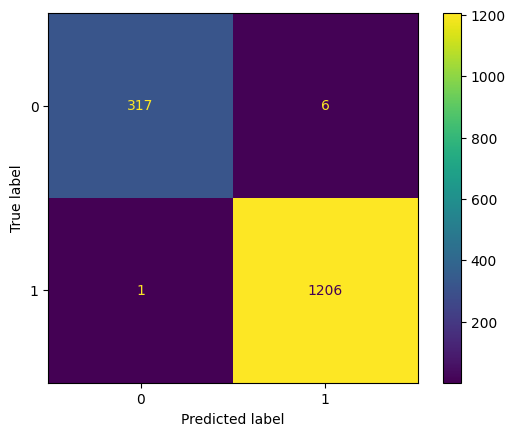

In [ ]:
#Create the model
from sklearn. linear_model import LogisticRegression
LR = LogisticRegression ()
LR. fit(X_train_std, y_train)

#Prediction
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
y_pred = LR. predict(X_test_std)
y_prob = LR. predict_proba(X_test_std)[:, 1]

#Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred) )
print("Confusion Matrix:")
ConfusionMatrixDisplay.from_estimator(LR, X_test_std, y_test)
print ("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

**Decision Tree**

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       323
           1       0.99      0.98      0.99      1207

    accuracy                           0.98      1530
   macro avg       0.96      0.97      0.97      1530
weighted avg       0.98      0.98      0.98      1530

Confusion Matrix:
ROC-AUC Score: 0.986079654030539


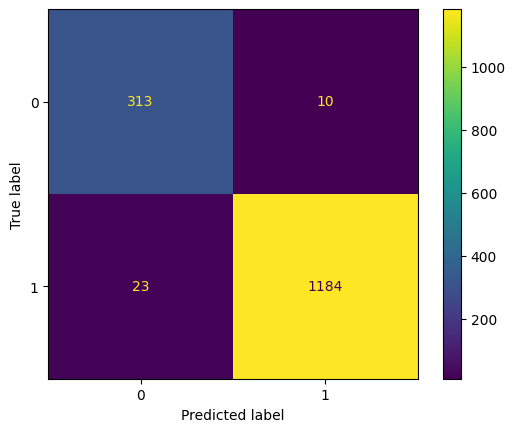

In [ ]:
#Create the model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_std, y_train)

#Predict on the test set
y_pred_dt = dt_model.predict(X_test_std)
y_proba_dt = dt_model.predict_proba(X_test_std)[:, 1]

#Evaluate performance
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_estimator(dt_model, X_test_std, y_test)

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_dt))

**RANDOM FOREST**

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       323
           1       0.99      1.00      0.99      1207

    accuracy                           0.99      1530
   macro avg       0.99      0.98      0.99      1530
weighted avg       0.99      0.99      0.99      1530

Confusion Matrix:
ROC-AUC Score: 0.9990740289487792


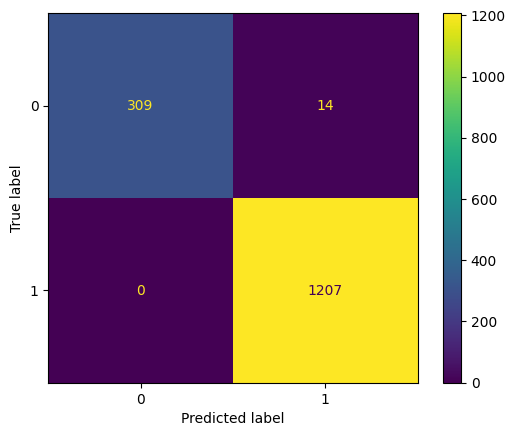

In [ ]:
# Import the model and evaluation tools
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_std, y_train)

#Predict
y_pred_rf = rf_model.predict(X_test_std)
y_proba_rf = rf_model.predict_proba(X_test_std)[:, 1]

#Evaluate
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_std, y_test)

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_rf))

**False Positives (FP):**
* Lowest in Logistic Regression (6)
* Highest in Random Forest (14)
* FP = costly in lending (you lend money to someone who defaults)

**False Negatives (FN):**
* Lowest in Random Forest (0)
* Highest in Decision Tree (23)
* FN = missed opportunity (rejecting someone who would have paid)

**Random Forest** shows the best balance, followed by Logistic Regression, then Decision Tree.

False Positives (FP) are most costly in lending --> giving money to borrowers who default.

False Negatives (FN) represent opportunity loss, but less risky.

**Best model: Random Forest** --> Highest accuracy and AUC

Extremely low false positives. Almost perfect true positives and true negatives

Business implications:
* Highly reliable in identifying good/bad loans
* Minimal financial loss due to bad loan approvals
* Very small number of missed opportunities

# **OPEN LOANS**

In [ ]:
#Select open loans
df_open = df[df['loan_status'].isin(['Current', 'Late', 'In Grace Period'])].copy()

In [ ]:
# Make sure 'issue_d' and other dates are datetime
df_open['issue_d'] = pd.to_datetime(df_open['issue_d'], errors='coerce')
df_open['earliest_cr_line'] = pd.to_datetime(df_open['earliest_cr_line'], errors='coerce')
df_open['last_pymnt_d'] = pd.to_datetime(df_open['last_pymnt_d'], errors='coerce')
df_open['last_credit_pull_d'] = pd.to_datetime(df_open['last_credit_pull_d'], errors='coerce')

df_open['credit_history_length'] = (df_open['issue_d'] - df_open['earliest_cr_line']).dt.days
df_open['months_since_last_payment'] = (df_open['issue_d'] - df_open['last_pymnt_d']).dt.days
df_open['months_since_last_pull'] = (df_open['issue_d'] - df_open['last_credit_pull_d']).dt.days


<ipython-input-23-165f07a5b5e5>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_open['earliest_cr_line'] = pd.to_datetime(df_open['earliest_cr_line'], errors='coerce')
<ipython-input-23-165f07a5b5e5>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_open['last_pymnt_d'] = pd.to_datetime(df_open['last_pymnt_d'], errors='coerce')
<ipython-input-23-165f07a5b5e5>:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_open['last_credit_pull_d'] = pd.to_datetime(df_open['last_credit_pull_d'], errors='coerce')


In [ ]:
# Drop originals
df_open.drop(columns=['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d'], errors='ignore', inplace=True)

In [ ]:
# Apply get_dummies using the same categories as in training
df_open = pd.get_dummies(df_open, drop_first=True)

# Align df_open with X_train (this ensures the same columns exist)
df_open_aligned = df_open.reindex(columns=X.columns, fill_value=0)

In [ ]:
X_open = df_open_aligned

# Transform and predict
from sklearn.impute import SimpleImputer

# Recreate and fit the imputer on your training data
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train)

X_open_imputed = imputer.transform(X_open)
X_open_std = scaler.transform(X_open_imputed)
df_open['predicted_default_prob'] = LR.predict_proba(X_open_std)[:, 0]

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Sort the loans by risk
high_risk = df_open[df_open['predicted_default_prob'] > 0.8]
df_open.sort_values(by='predicted_default_prob', ascending=False).head(10)


,id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,revol_util_99%,revol_util_99.3%,revol_util_99.5%,revol_util_99.6%,revol_util_99.8%,revol_util_99.9%,initial_list_status_w,application_type_Joint App,hardship_flag_Y,predicted_default_prob
618164,145155454,40000.0,40000.0,40000.0,1015.09,200000.0,0.27,0.0,700.0,704.0,...,False,False,False,False,False,False,True,True,True,1.0
545325,138207091,36000.0,36000.0,36000.0,1168.49,60000.0,29.80,2.0,680.0,684.0,...,False,False,False,False,False,False,True,True,False,1.0
652303,143865367,40000.0,40000.0,40000.0,1057.98,56000.0,31.18,0.0,710.0,714.0,...,False,False,False,False,False,False,True,True,False,1.0
523828,138626080,40000.0,40000.0,40000.0,992.17,30000.0,21.60,0.0,745.0,749.0,...,False,False,False,False,False,False,True,True,False,1.0
486377,140863993,40000.0,40000.0,40000.0,880.71,144000.0,18.15,0.0,675.0,679.0,...,False,False,False,False,False,False,True,False,False,1.0
607552,135777100,35000.0,35000.0,35000.0,1063.94,44720.0,37.47,0.0,660.0,664.0,...,False,False,False,False,False,False,True,True,False,1.0
734776,141096177,35000.0,35000.0,34975.0,1054.35,27194.0,40.16,0.0,700.0,704.0,...,False,False,False,False,False,False,False,True,False,1.0
352443,135378442,40000.0,40000.0,40000.0,961.92,73000.0,17.54,0.0,670.0,674.0,...,False,False,False,False,False,False,True,False,False,1.0
560270,137773551,40000.0,40000.0,40000.0,952.02,80000.0,14.70,0.0,735.0,739.0,...,False,False,False,False,False,False,True,False,False,1.0
284582,129249074,40000.0,40000.0,40000.0,922.05,113000.0,18.24,0.0,715.0,719.0,...,False,False,False,False,False,False,True,False,True,1.0


In [ ]:
# Estimate finantial lost
estimated_loss = high_risk['loan_amnt'].sum()
print(f"Estimated risk exposure: ${estimated_loss:,.2f}")

Estimated risk exposure: $19,135,725.00
